In [1]:
import torch
import torchvision
import numpy as np
from matplotlib import pyplot as plt
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
#get name of notebook this kernel runs
notebook_name = os.path.basename(globals()['__session__'])  # Get the name without extension
#remove the extension
notebook_name = os.path.splitext(notebook_name)[0]

In [5]:
#find experiment_files then go to data then go to coil100
current_path = os.getcwd()
max_depth = 10  # Limit the search to a maximum depth
while not os.path.exists(os.path.join(current_path, "experiment_files", "data", "coil-100")):
    current_path = os.path.dirname(current_path)
    max_depth -= 1
    if max_depth <= 0:
        raise FileNotFoundError("Could not find the 'coil-100' directory within the specified depth.")

In [6]:
# coil 100 does not have black backgrounds but grey ibes
sampleimage= torchvision.io.read_image(os.path.join(current_path, "experiment_files", "data", "coil-100", "obj1__0.png"))

In [7]:
#get color of first pixel


In [8]:
from dataset.coil import COIL100Dataset,AdjustedGridResample
from utils.transform_sequence import create_sampler, TransformSequence
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import AffineTransformDataset

dataset = 'coil100' # or 'fmnist'
batch_size = 64

dataset_all = COIL100Dataset(os.path.join(current_path, "experiment_files", "data", "coil-100"), transform=torchvision.transforms.ToTensor())
dataset_train, dataset_val, dataset_test_pre = torch.utils.data.random_split(dataset_all, [0.8, 0.1, 0.1], generator=torch.Generator().manual_seed(42))
background_color = dataset_all[0][0][:, 0, 0].numpy()

adjusted_grid_resample = AdjustedGridResample(background_color)



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

#TODO for some reason using adjusted_grid_resample decreas the performance during search but why?

transform_seq_sampling= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=adjusted_grid_resample,device="cpu",reflect=True,use_individual_param_correction=False)

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=adjusted_grid_resample,device="cuda",reflect=True,use_individual_param_correction=False)

transform =create_sampler(transform_seq_sampling)


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size,resample_func=adjusted_grid_resample)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)


In [9]:
dataset_val_transformed = AffineTransformDataset(dataset_val,transform,return_transformation=False,batch_size=batch_size,resample_func=adjusted_grid_resample)

val_loader_transformed = torch.utils.data.DataLoader(dataset_val_transformed, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

In [10]:
dataset_train_transformed = AffineTransformDataset(dataset_train,transform,return_transformation=False,batch_size=batch_size,resample_func=adjusted_grid_resample)
train_loader_transformed = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)

In [11]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4901161e-08..0.992157].


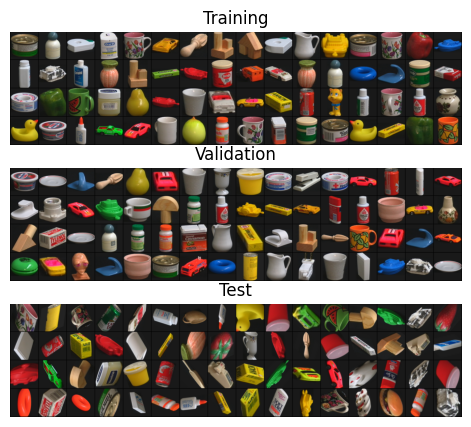

In [12]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4901161e-08..0.992157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.450581e-09..0.992157].


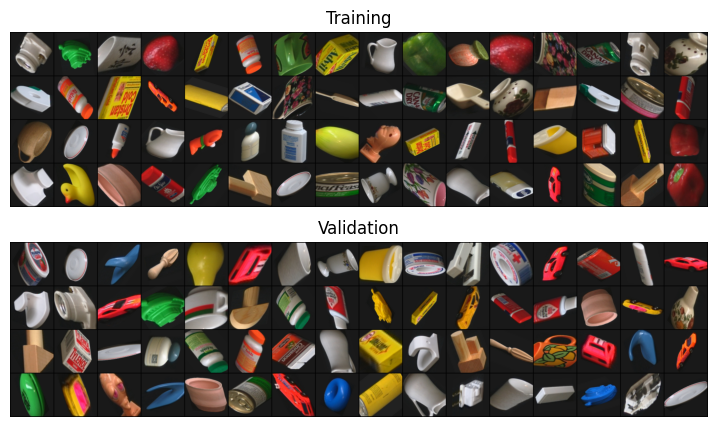

In [13]:
#test images
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader_transformed))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader_transformed))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())

axs[0].set_title('Training')
axs[1].set_title('Validation')

for ax in axs.flat:
    ax.axis('off')

In [14]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric.pth")

In [15]:
import torch.nn as nn

In [16]:
import pytorch_lightning as pl
import os

model_path = modelpath

model = nn.Sequential(
    nn.AvgPool2d(kernel_size=4, stride=4),
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x32x32
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x16x16
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x16x16
    nn.BatchNorm2d(64),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x8x8
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, 100)
)



# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\coil100_metric.pth


In [17]:
model.cuda().eval()

Sequential(
  (0): AvgPool2d(kernel_size=4, stride=4, padding=0)
  (1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): GELU(approximate='none')
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): GELU(approximate='none')
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=3136, out_features=128, bias=True)
  (11): Dropout(p=0.5, inplace=False)
  (12): GELU(approximate='none')
  (13): Linear(in_features=128, out_features=100, bias=True)
)

In [18]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 1.0.


In [19]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.2833333333333333.


In [20]:
from pytorch_lightning.callbacks import ModelCheckpoint
import pytorch_lightning as pl
import os
import torch
import torch.nn as nn

modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric3.pth")
model_path = modelpath

model2 = nn.Sequential(
    nn.AvgPool2d(kernel_size=4, stride=4,padding=1),
    nn.Conv2d(3, 128, kernel_size=3, stride=1, padding=1),  # Output: 32x32x32
    nn.BatchNorm2d(128),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x16x16
    nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # Output: 64x16x16
    nn.BatchNorm2d(256),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x8x8
    nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),  # Output: 64x16x16
    nn.BatchNorm2d(256),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 256x4x4
    nn.Flatten(),
    nn.Linear(256 * 4 * 4, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, 100)
)

if os.path.exists(model_path) and True:
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")

    # LightningModule wrapper
    lightning_model = Classifier(
        model2,
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # Callbacks
    progress_bar     = MyProgressBar()
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True,
        dirpath=os.path.join(os.getcwd(), "model"),
        filename=f"{dataset}_val_acc_best"
    )

    # Trainer
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar, checkpoint_callback],
    )

    # Train
    trainer.fit(lightning_model, train_loader_transformed, val_loader_transformed)

    # 1) Reload LightningModule from best ckpt
    best_ckpt = checkpoint_callback.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    lightning_model = Classifier.load_from_checkpoint(
        best_ckpt,
        model=model2,  # supply same nn.Sequential structure
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # 2) Extract & save raw nn.Sequential weights
    model2.load_state_dict(lightning_model.model.state_dict())
    torch.save(model2.state_dict(), model_path)
    print(f"Best model saved to {model_path}")


with torch.no_grad():
    model2.cuda().eval()
    test_acc = 0
    for data, target in val_loader_transformed:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

model2 = None
torch.cuda.empty_cache()


Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\coil100_metric3.pth
Mean accuracy on the transformed test set: 0.9236111111111112.


In [21]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric2.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model2 = nn.Sequential(
    nn.AvgPool2d(kernel_size=4, stride=4),
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x32x32
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x16x16
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x16x16
    nn.BatchNorm2d(64),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, 100)
)

if os.path.exists(model_path) and True:
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")

    # LightningModule wrapper
    lightning_model = Classifier(
        model2,
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # Callbacks
    progress_bar     = MyProgressBar()
    checkpoint_callback = ModelCheckpoint(
        monitor='val_acc',
        mode='max',
        save_top_k=1,
        verbose=True,
        dirpath=os.path.join(os.getcwd(), "model"),
        filename=f"{dataset}_val_acc_best"
    )

    # Trainer
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar, checkpoint_callback],
    )

    # Train
    trainer.fit(lightning_model, train_loader_transformed, val_loader_transformed)

    # 1) Reload LightningModule from best ckpt
    best_ckpt = checkpoint_callback.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    lightning_model = Classifier.load_from_checkpoint(
        best_ckpt,
        model=model2,  # supply same nn.Sequential structure
        optimizer_class=torch.optim.AdamW,
        optimizer_params={"lr": 1e-3}
    )

    # 2) Extract & save raw nn.Sequential weights
    model2.load_state_dict(lightning_model.model.state_dict())
    torch.save(model2.state_dict(), model_path)
    print(f"Best model saved to {model_path}")

with torch.no_grad():
    model2.cuda().eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')


model2 = None
torch.cuda.empty_cache()

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\coil100_metric2.pth
Mean accuracy on the transformed test set: 0.9291666666666667.


In [22]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'13',flatten=True).eval()

In [23]:
#extract embeddings and fit NNDistanceConfidence()
embeddings=[]
classes =[]
from confidence.direct.logit_based import EnergyConfidence
energy_conf_module = EnergyConfidence()

logits = []

for batch in train_loader:
    emb,logit = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())
    logits.append(logit.detach().cpu().numpy())


embeddings = np.vstack(embeddings)
classes = np.hstack(classes)
logits = np.vstack(logits)
#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings_sampled = embeddings[indices]
    classes_sampled = classes[indices]
    logits_sampled = logits[indices]
else:
    embeddings_sampled = embeddings
    classes_sampled = classes
    logits_sampled = logits


In [24]:
import search.shgo
import importlib
importlib.reload(search.shgo)

<module 'search.shgo' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\shgo.py'>

In [25]:
di = search.shgo.SHGO(selection_method="topk")
di_no_grad = search.shgo.SHGO(selection_method="topk",local_max_steps=0)

In [26]:
def evaluate_conf(model, di, problem, test_loader, max_batch_override=None):
    if max_batch_override is not None:
        problem.max_batch_size = max_batch_override
    with torch.no_grad():
        test_acc_sim = 0
        counter = 0
        for data, target in tqdm.tqdm(test_loader):
            data, target = data.cuda(), target.cuda()
            with torch.enable_grad():
                res = di.optimize(problem, data.cuda(), y=target.cuda())
                res = list(res)
            torch.cuda.empty_cache()
            res[0] = res[0].detach()  # Detach the result to avoid gradients
            res[1] = res[1].detach()  # Detach the result to avoid gradients
            # Apply the transformation and get predictions
            x_transformed2 = problem.transform(data.cuda(), res[0])
            logits = model(x_transformed2)
            output = logits.argmax(dim=-1)
            test_acc_sim += output.eq(target).sum().cpu().detach().item()
            counter += output.shape[0]

    test_acc_sim /= counter
    return test_acc_sim


import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
from utils.transformation_problem import TransformationProblem



In [27]:
conf_mod_nn_pytorch = SinglePassConfidence(model, EnergyConfidence())
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch, transform_seq, consolidate_method="consolidate_simple")
evaluate_conf(model, di, problem_nn_pytorch, test_loader)

100%|██████████| 12/12 [00:04<00:00,  2.67it/s]


0.7652777777777777

In [38]:
filter_correct = True  # Set to False to include all samples
embeddings22 = []
images22 = []
classes22 = []
logits22 = []
from confidence.utils import ModelInputOutputWrapper
dual_ouput_model22 = ModelInputOutputWrapper(model,"13",capture_modes=["input"])

for data, target in train_loader:
    data_cuda = data.cuda()
    emb_batch,logits_batch = dual_ouput_model22(data_cuda)
    #emb_batch2 = model[:-1](data_cuda)
    #assert torch.allclose(emb_batch, emb_batch2), "Embeddings do not match between models."
    emb_batch = emb_batch.detach().cpu().numpy()
    target_np = target.numpy()

    if filter_correct:
        mask = target_np == logits_batch.argmax(dim=-1).cpu().numpy()
        emb_np = emb_batch[mask]
        class_np = target_np[mask]
    else:
        emb_np = emb_batch.detach().cpu().numpy()
        class_np = target_np

    embeddings22.append(emb_np)
    classes22.append(class_np)

embeddings22 = np.vstack(embeddings22)
classes22 = np.hstack(classes22)







from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = ViMTorchConfidence(model.eval(),n_dim=100,use_energy=True)
gmm_conf.fit(torch.tensor(embeddings22).cuda(),y=torch.tensor(classes22).cuda())
gmm_conf.cuda()

conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model22, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 12/12 [00:03<00:00,  3.92it/s]

Mean accuracy on the transformed test set with GD: 0.775.


In [27]:


from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine")
nn_pytorch.fit(torch.tensor(embeddings_sampled).cuda())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9138888888888889.


In [28]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine")
nn_pytorch.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9138888888888889.


In [29]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.00001)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9194444444444444.


In [30]:


from confidence.direct.prob_based import EntropyConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,NNGuideSplitConfidence


class one_confidence(nn.Module):
    def __init__(self):
        super().__init__()
        self.EnergyConfidence = EnergyConfidence()

    def forward(self, x,y=None):
        return torch.ones_like(x)[:,0]

class one_confidence2(nn.Module):
    def __init__(self):
        super().__init__()
        self.EnergyConfidence = EnergyConfidence()

    def forward(self, x,y=None):
        return self.EnergyConfidence(x,y)

conf_split = NNGuideSplitConfidence(one_confidence2(), k=3)
conf_split.fit((torch.tensor(embeddings_sampled).cpu(), torch.tensor(logits_sampled).cpu()))
conf_split.cuda()
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7069444444444445.


In [31]:
nn_pytorch.save("test.pth")
nn_pytorch.load("test.pth")

In [32]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7152777777777778.


In [33]:
problem_nn_pytorch.calculate_error(data.cuda(), torch.zeros(data.shape[0],5).cuda())

(tensor([-118.6773,  -70.6965, -149.4469,  -50.5598,  -80.4521,  -26.3468,
           -3.7733,   -8.5484,  -13.3032,  -72.7061,  -40.8438, -102.7785,
          -87.9188,  -64.5267,   -9.6821,  -46.6525], device='cuda:0',
        grad_fn=<NegBackward0>),
 tensor([87, 37, 87, 65, 67, 76, 26, 59, 15, 36, 36, 14, 62, 43,  6, 67],
        device='cuda:0'))

In [34]:
from confidence.unsupervised.classic.lle import LLEResidualConfidence

lle_conf = LLEResidualConfidence()
lle_conf.fit(torch.tensor(embeddings_sampled).cpu())
lle_conf.cuda()
conf_split = SplitConfidence(lle_conf, EnergyConfidence(), mult=False, b=0.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8388888888888889.


In [35]:
from confidence.unsupervised.classic.openmax import OpenMaxConfidence
from confidence.control.split import PredictedSplitConfidence

lle_conf = OpenMaxConfidence()
lle_conf.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())
lle_conf.cuda()
conf_split = PredictedSplitConfidence(lle_conf, EnergyConfidence(), mult=False, b=0.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5347222222222222.


In [36]:
#extract logits from train
logits2 = []
classes2 = []
for batch in train_loader:
    logits_batch = model(batch[0].cuda())
    logits2.append(logits_batch.detach().cpu().numpy())
    classes2.append(batch[1].detach().cpu().numpy())
logits2 = np.vstack(logits2)
classes2 = np.hstack(classes2)

In [37]:
from confidence.unsupervised.classic.openmax import OpenMaxConfidence
from confidence.control.split import PredictedSplitConfidence

lle_conf2 = OpenMaxConfidence()
lle_conf2.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf2.cuda()
conf_split = PredictedSplitConfidence(lle_conf,lle_conf2, mult=False, a=0.0,b=1.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5333333333333333.


In [38]:
from confidence.unsupervised.classic.openmax3 import OpenMaxConfidenceNumpy as OpenMaxConfidence2
from confidence.control.split import PredictedSplitConfidence
import tqdm
lle_conf3 = OpenMaxConfidence2()
lle_conf3.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf3.cuda()

conf_mod_lle = SinglePassConfidence(model, lle_conf3)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di_no_grad.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
    break
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

  0%|          | 0/12 [00:05<?, ?it/s]

Mean accuracy on the transformed test set with GD: 0.21875.


In [39]:
from confidence.unsupervised.classic.openmax3 import OpenMaxConfidence as OpenMaxConfidence3
from confidence.control.split import PredictedSplitConfidence
import tqdm
lle_conf3 = OpenMaxConfidence3()
lle_conf3.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf3.cuda()

conf_mod_lle = SinglePassConfidence(model, lle_conf3)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di_no_grad.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

100%|██████████| 12/12 [00:01<00:00,  7.20it/s]

Mean accuracy on the transformed test set with GD: 0.24583333333333332.


In [40]:
from confidence.unsupervised.classic.nn import NNDistanceConfidence

nearest_neighbor_confidence = NNDistanceConfidence(index_type="ivfpq", number_of_neighbors=3)
nearest_neighbor_confidence.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nearest_neighbor_confidence.cuda()
conf_split = SplitConfidence(nearest_neighbor_confidence, EnergyConfidence(), mult=False, b=0.0)
conf_mod = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8694444444444445.


In [41]:

from confidence.unsupervised.classic.gmm import GaussianMixtureConfidence

gmm_conf = GaussianMixtureConfidence(n_components=10, covariance_type="full")
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, 

Mean accuracy on the transformed test set with GD: 0.7583333333333333.


In [42]:

from confidence.unsupervised.classic.isolation import HardIsolationForestConfidence

gmm_conf = HardIsolationForestConfidence(contamination=0.01,max_features=10)
gmm_conf.fit(embeddings)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.22916666666666666.


In [43]:


from confidence.unsupervised.classic.trust_score import TrustScoreTorchConfidence

gmm_conf = TrustScoreTorchConfidence()
gmm_conf.device = "cuda"
gmm_conf.fit(torch.tensor(embeddings_sampled).cuda(),torch.tensor(classes_sampled).cuda())
gmm_conf.cuda()
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=None)

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8902777777777777.


In [44]:


from confidence.unsupervised.classic.kde import KDEConfidence

gmm_conf = KDEConfidence(bandwidth=0.2, kernel="gaussian")
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.9125.


In [45]:

from confidence.unsupervised.classic.osvm import OCSVMPredictiveConfidence

gmm_conf = OCSVMPredictiveConfidence(nu=0.01)
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.11944444444444445.


In [46]:
import confidence.unsupervised.classic.pca
import importlib

importlib.reload(confidence.unsupervised.classic.pca)
from confidence.unsupervised.classic.pca import PCATorchConfidence

gmm_conf = PCATorchConfidence(n_components=32)
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.4638888888888889.


In [47]:




from confidence.unsupervised.classic.gaussian import ImageGaussianConfidence

gmm_conf = ImageGaussianConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.2986111111111111.


In [48]:
from confidence.unsupervised.classic.dice import DICEConfidence


gmm_conf = DICEConfidence(model,percentile=0.95)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7680555555555556.


In [49]:


from confidence.unsupervised.classic.dice import DICEConfidence


gmm_conf = DICEConfidence(model,percentile=0.01)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7694444444444445.


In [50]:






from confidence.unsupervised.classic.kl_matching import KLMatchingConfidence

gmm_conf = KLMatchingConfidence()
gmm_conf.fit(torch.tensor(logits2).cuda(),y=torch.tensor(classes2).cuda())
gmm_conf.cuda()
gmm_conf = SinglePassConfidence(model, gmm_conf)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 12/12 [00:07<00:00,  1.51it/s]

Mean accuracy on the transformed test set with GD: 0.7402777777777778.


In [51]:
from confidence.unsupervised.classic.lof import LOFTorchConfidence

gmm_conf = LOFTorchConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 12/12 [00:03<00:00,  3.93it/s]

Mean accuracy on the transformed test set with GD: 0.6194444444444445.


In [52]:
from confidence.unsupervised.classic.mahalanobis_relative import RelativeMahalanobisConfidence

gmm_conf = RelativeMahalanobisConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 12/12 [00:03<00:00,  3.87it/s]

Mean accuracy on the transformed test set with GD: 0.5583333333333333.


In [53]:
torch.cuda.empty_cache()

In [54]:
from confidence.unsupervised.classic.pyood_wrapper import MahalanobisConfidence

gmm_conf = MahalanobisConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 12/12 [00:04<00:00,  2.55it/s]

Mean accuracy on the transformed test set with GD: 0.8208333333333333.


In [55]:

from confidence.unsupervised.classic.mtc import ManifoldTangentConfidence

gmm_conf = ManifoldTangentConfidence(n_components=int(embeddings.shape[-1]/16),n_clusters=50)
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Unsupervised clustering: running k-means
fitted


100%|██████████| 12/12 [00:02<00:00,  4.06it/s]

Mean accuracy on the transformed test set with GD: 0.8888888888888888.


In [56]:

from confidence.unsupervised.classic.SHE import SHETorchConfidence
from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = SHETorchConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

For correct functionality one must prefilter embeddings to only keep correctly classified ones.
fitted


100%|██████████| 12/12 [00:02<00:00,  4.10it/s]

Mean accuracy on the transformed test set with GD: 0.4222222222222222.


In [33]:
from confidence.model.single_pass import SinglePassConfidence
from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = ViMTorchConfidence(model.eval(),n_dim=32,use_energy=True)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 12/12 [00:03<00:00,  3.67it/s]

Mean accuracy on the transformed test set with GD: 0.7291666666666666.


In [58]:
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import BasicAutoencoderConfidence

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = BasicAutoencoderConfidence(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 133 K  | tr

Epoch 9: 100%|██████████| 45/45 [00:00<00:00, 204.35it/s, v_num=390, train_loss=1.000]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 45/45 [00:00<00:00, 192.96it/s, v_num=390, train_loss=1.000]
Mean accuracy on the transformed test set with GD: 0.7888888888888889.


In [59]:
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import ConditionalAutoencoderConfidence
num_classes = 100
encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16+num_classes, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ConditionalAutoencoderConfidence(encoder_lin, decoder_lin,num_classes=num_classes,trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 133 K  | train
1 | decoder | Sequential | 146 K  | train
-----------------------------------------------
280 K     Trainable params
0         Non-trainable params
280 K     Total params
1.122     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Epoch 4: 100%|██████████| 45/45 [00:00<00:00, 192.69it/s, v_num=391, train_loss=3.290]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 45/45 [00:00<00:00, 184.02it/s, v_num=391, train_loss=3.290]
Mean accuracy on the transformed test set with GD: 0.46111111111111114.


In [60]:


from confidence.unsupervised.ml.deepsvd import DeepSVDDConfidence

encoder_lin_deep = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 128,bias=False),
    nn.LeakyReLU(),
    nn.Linear(128, 128,bias=False),
    nn.LeakyReLU(),
    nn.Linear(128, 16,bias=False)
).cuda()
gmm_conf = DeepSVDDConfidence(encoder_lin_deep,objective="one-class",trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128},weight_decay=0.001)
gmm_conf.cuda()
gmm_conf.fit(torch.tensor(embeddings).cuda()).cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


bias terms are not recommended for DeepSVDD, this is not checked here. Similary unbounded activations are prefered and weight decay/reg to avoid trivial solutions.



  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 34.8 K | train
-----------------------------------------------
34.8 K    Trainable params
0         Non-trainable params
34.8 K    Total params
0.139     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


Epoch 4: 100%|██████████| 45/45 [00:00<00:00, 238.96it/s, v_num=392, train_loss=0.0132] 

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 45/45 [00:00<00:00, 231.58it/s, v_num=392, train_loss=0.0132]
Mean accuracy on the transformed test set with GD: 0.525.


In [61]:
from confidence.unsupervised.ml.vae import VAEConfidence
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)


encoder_lin2 = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
).cuda()

class VAEEncoder(torch.nn.Module):
    def __init__(self,model,indim=128,outdim=16):
        super(VAEEncoder, self).__init__()
        self.model = model
        self.lin1= nn.Linear(indim, outdim)
        self.lin2 = nn.Linear(indim, outdim)
    def forward(self, x):
        x = self.model(x)
        return self.lin1(x), self.lin2(x)

encoder_lin2 = VAEEncoder(encoder_lin2).cuda()




decoder_lin2 = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = VAEConfidence(encoder_lin2, decoder_lin2,latent_dim=16,mode="elbo",beta=0.1,
                         trainer_kwargs={"max_epochs": 15},
                         dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | VAEEncoder | 135 K  | train
1 | decoder | Sequential | 133 K  | train
-----------------------------------------------
269 K     Trainable params
0         Non-trainable params
269 K     Total params
1.079     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 45/45 [00:00<00:00, 179.76it/s, v_num=393, train_loss_step=4.490, train_loss_epoch=4.440]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 45/45 [00:00<00:00, 171.54it/s, v_num=393, train_loss_step=4.490, train_loss_epoch=4.440]
Mean accuracy on the transformed test set with GD: 0.6680555555555555.


In [62]:
from confidence.unsupervised.ml.flow import FlowConfidence
import normflows as nf
# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(128)

# Define list of flows
num_layers = 2
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([64, 128, 128, 128], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))

flow = nf.NormalizingFlow(base, flows)

gmm_conf = FlowConfidence(flow, decoder_lin2,
                         trainer_kwargs={"max_epochs": 20},
                         dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\utilities\parsing.py:209: Attribute 'input_dim' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['input_dim'])`.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type            | Params | Mode 
------------------------------------------------------
0 | flow      | NormalizingFlow | 82.9 K | train
1 | input_dim | Sequential      | 133 K  | train
------------------------------------------------------
216 K     Trainable params
0         Non-trainable params
216 K     Total params
0.867     Total estimated model params size (MB)
35        Modu

Epoch 19: 100%|██████████| 45/45 [00:00<00:00, 137.77it/s, v_num=394, train_loss_step=204.0, train_loss_epoch=240.0]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 45/45 [00:00<00:00, 132.50it/s, v_num=394, train_loss_step=204.0, train_loss_epoch=240.0]


FlowConfidence(
  (flow): NormalizingFlow(
    (q0): DiagGaussian()
    (flows): ModuleList(
      (0): AffineCouplingBlock(
        (flows): ModuleList(
          (0): Split()
          (1): AffineCoupling(
            (param_map): MLP(
              (net): Sequential(
                (0): Linear(in_features=64, out_features=128, bias=True)
                (1): LeakyReLU(negative_slope=0.0)
                (2): Linear(in_features=128, out_features=128, bias=True)
                (3): LeakyReLU(negative_slope=0.0)
                (4): Linear(in_features=128, out_features=128, bias=True)
              )
            )
          )
          (2): Merge()
        )
      )
      (1): Permute()
      (2): AffineCouplingBlock(
        (flows): ModuleList(
          (0): Split()
          (1): AffineCoupling(
            (param_map): MLP(
              (net): Sequential(
                (0): Linear(in_features=64, out_features=128, bias=True)
                (1): LeakyReLU(negative_slope=0.0)


In [63]:
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.2513888888888889.


In [64]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ASHConfidence

gmm_conf = ASHConfidence(model[:-5],model[-5:],variant="ash-s",percentile=0.85)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.6944444444444444.


In [36]:
model.eval()

Sequential(
  (0): AvgPool2d(kernel_size=4, stride=4, padding=0)
  (1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): GELU(approximate='none')
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): GELU(approximate='none')
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=3136, out_features=128, bias=True)
  (11): Dropout(p=0.5, inplace=False)
  (12): GELU(approximate='none')
  (13): Linear(in_features=128, out_features=100, bias=True)
)

In [47]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(model[:-3],model[-3:],threshold=50.0)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7736111111111111.


In [ ]:
dsfgsf

In [67]:
dual_output_model2 = ModelInputWrapper(model[:-2],'11',flatten=True).eval()

In [68]:
knn_conf = KNNConfidence(k=3,metric="cosine")
knn_conf.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())


KNNConfidence()

In [69]:
conf = SplitConfidence(knn_conf, EnergyConfidence(), mult=True, b=0.0)

In [70]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(dual_output_model2,model[-2:],threshold=3.0,index_feat=1,confidence=conf)




problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.6069444444444444.


In [71]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = SinglePassConfidence(dual_ouput_model,conf,index=1)

problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8083333333333333.


In [72]:
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)

from confidence.supervised.ml.contrastive_autoencoder import ContrastiveAutoencoder

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ContrastiveAutoencoder(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},distance_type="l2",mode="reconstruction").cuda()
sampling_strategy = GaussianSamplingStrategyLatent()
gmm_conf.negative_sampling_module =BatchNegativeSampler(sampling_strategy)


gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "l2"
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | encoder                  | Sequential           | 133 K  | train
1 | decoder                  | Sequential           | 133 K  | train
2 | negative_sampling_module | BatchNegativeSampler | 0      | train
--------------------------------------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.071     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 45/45 [00:00<00:00, 166.56it/s, v_num=395, train_loss_step=0.941, train_loss_epoch=0.909]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 45/45 [00:00<00:00, 158.35it/s, v_num=395, train_loss_step=0.941, train_loss_epoch=0.909]
Mean accuracy on the transformed test set with GD: 0.7833333333333333.


In [73]:
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)

from confidence.supervised.ml.contrastive_autoencoder import ContrastiveAutoencoder

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ContrastiveAutoencoder(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},distance_type="l2",mode="reconstruction").cuda()
sampling_strategy = GaussianSamplingStrategyLatent()
gmm_conf.negative_sampling_module =BatchNegativeSampler(sampling_strategy)


gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "l2"
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | encoder                  | Sequential           | 133 K  | train
1 | decoder                  | Sequential           | 133 K  | train
2 | negative_sampling_module | BatchNegativeSampler | 0      | train
--------------------------------------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.071     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 45/45 [00:00<00:00, 163.94it/s, v_num=396, train_loss_step=0.909, train_loss_epoch=0.889]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 45/45 [00:00<00:00, 156.53it/s, v_num=396, train_loss_step=0.909, train_loss_epoch=0.889]
Mean accuracy on the transformed test set with GD: 0.7347222222222223.
